Warnings

In [68]:
import warnings
warnings.filterwarnings('ignore')

Libraries

In [69]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
from IPython.core.display import HTML

In [71]:
HTML("""
<style>
h1 { color: blue !important; }
h2 { color: green !important; }
</style>
""")

In [72]:
data = pd.read_csv('wine_data.csv')

In [73]:
data.describe(include='all')

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,1.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,1.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,1.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,2.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,3.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,3.000000


In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Customer_Segment      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [75]:
data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [76]:
data.Customer_Segment.value_counts()

Customer_Segment
2    71
1    59
3    48
Name: count, dtype: int64

In [77]:
data

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


Splitting Data

In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [79]:
X = data

In [80]:
X_train, X_test = train_test_split(X, test_size=.2, random_state=42)

In [81]:
y_train = X_train.pop('Customer_Segment')
y_test = X_test.pop('Customer_Segment')

In [82]:
features = X_train.columns

Scaling Data

In [83]:
scaler = StandardScaler()

In [84]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Apply PCA

In [85]:
from sklearn.decomposition import PCA

In [86]:
model = PCA(n_components=5)

In [88]:
model.fit_transform(X_train)
model.transform(X_test)
print(f"Explained Variance Ratio: {model.explained_variance_ratio_}")

Explained Variance Ratio: [0.35900066 0.18691934 0.11606557 0.07371716 0.0665386 ]


Evaluating number of components

In [90]:
components = list()
expVarRatio = list()

for i in range(2, 14):
    model = PCA(n_components=i)
    model.fit_transform(X_train)
    model.transform(X_test)
    components.append(i)
    expVarRatio.append(model.explained_variance_ratio_.sum())
    print(f"Number of components: {i}")
    print(f"Explained Variance Ration: {model.explained_variance_ratio_.sum()}")

Number of components: 2
Explained Variance Ration: 0.54592000222866
Number of components: 3
Explained Variance Ration: 0.6619855707386525
Number of components: 4
Explained Variance Ration: 0.735702728943411
Number of components: 5
Explained Variance Ration: 0.8022413242841141
Number of components: 6
Explained Variance Ration: 0.8507871409164787
Number of components: 7
Explained Variance Ration: 0.8927375570607682
Number of components: 8
Explained Variance Ration: 0.9195767788723952
Number of components: 9
Explained Variance Ration: 0.9430513808011616
Number of components: 10
Explained Variance Ration: 0.9619487172898267
Number of components: 11
Explained Variance Ration: 0.9791081505791053
Number of components: 12
Explained Variance Ration: 0.9917374327649615
Number of components: 13
Explained Variance Ration: 1.0000000000000002


Explained Variance Ration Vs Components

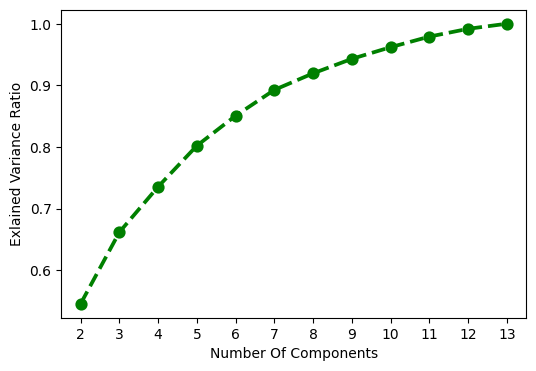

In [111]:
fig = plt.figure(figsize=(6, 4))
sns.pointplot(x=components, y=expVarRatio, linestyles='--', color='green', markers='o')
plt.xlabel('Number Of Components')
plt.ylabel('Exlained Variance Ratio')
plt.show()

PCA based on amount of Information - (90% information as Standard)

In [95]:
model = PCA(n_components=0.90)

In [96]:
model.fit_transform(X_train)
model.transform(X_test)
print(f"Number of components: {model.n_components_}")

Number of components: 8


Using PCA for visualization

In [115]:
model = PCA(n_components=2)

X_train_pca = model.fit_transform(X_train)

In [121]:
df = pd.DataFrame(X_train_pca, columns=['Component_1', 'Component_2'])

In [123]:
df['Customer_Segment'] = y_train.values

Plotting the data

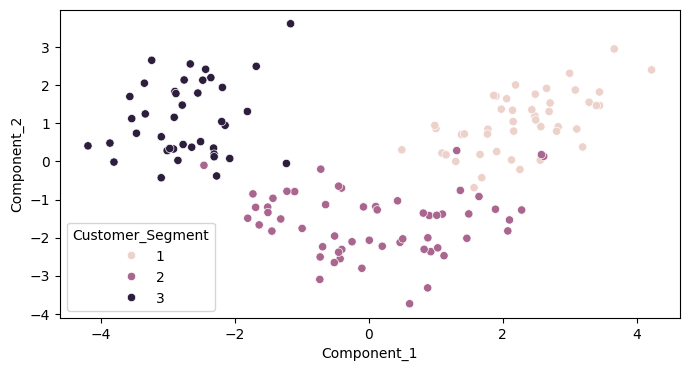

In [127]:
fig = plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Component_1', y='Component_2', hue='Customer_Segment')
plt.show()